# Churn Feature Engineering 07-1 - First Try

이 노트북은 초기 feature engineering 실험 기록이다. 단순 함수형 feature engineering을 원본 Stacking 모델과 비교하고, 왜 개선이 제한적이었는지 확인한다.


## 피쳐 설명

이 노트북은 첫 번째 feature engineering 실험으로, 원본 feature set에 사용 강도, engagement, 위험 flag, 구간화, 범주 조합 피쳐를 넓게 추가해 성능 변화를 확인한다.

| 구분 | 피쳐명 | 설명 |
| --- | --- | --- |
| 사용 강도 | `watch_time_per_session` | 주당 평균 시청 시간을 주당 시청 세션 수로 나눈 세션당 평균 시청 시간 |
| 사용 강도 | `watch_sessions_per_account_month` | 계정 연령 대비 주당 시청 세션 수 |
| 사용 강도 | `session_count_per_account_month` | 계정 연령 대비 집계 기간 내 접속 세션 수 |
| 비활성 | `inactive_ratio` | 계정 연령 대비 마지막 로그인 이후 경과 기간 비율 |
| Engagement | `rating_score_100` | 평균 콘텐츠 평점과 앱 평점을 0~100 범위로 변환한 점수 |
| Engagement | `engagement_score` | 완료율, 추천 클릭률, 평점 점수를 평균낸 종합 참여도 점수 |
| Engagement | `watch_engagement_score` | 완료율, 추천 클릭률, 시청 시간을 결합한 시청 중심 참여도 점수 |
| 위험 flag | `long_inactive_flag` | 마지막 로그인 이후 30일 이상 경과한 사용자 flag |
| 위험 flag | `very_long_inactive_flag` | 마지막 로그인 이후 45일 이상 경과한 사용자 flag |
| 위험 flag | `low_watch_time_flag` | 주당 평균 시청 시간이 낮은 사용자 flag |
| 위험 flag | `low_sessions_flag` | 주당 시청 세션 수가 낮은 사용자 flag |
| 위험 flag | `low_completion_flag` | 콘텐츠 완료율이 낮은 사용자 flag |
| 위험 flag | `low_recommendation_click_flag` | 추천 클릭률이 낮은 사용자 flag |
| 위험 flag | `low_app_rating_flag` | 앱 평가가 낮은 사용자 flag |
| 위험 flag | `short_account_flag` | 가입 기간이 짧은 사용자 flag |
| 조합 flag | `basic_mobile_flag` | Basic 요금제와 Mobile 중심 사용 조합 |
| 조합 flag | `basic_long_inactive_flag` | Basic 요금제와 장기 미접속 조합 |
| 조합 flag | `mobile_long_inactive_flag` | Mobile 중심 사용과 장기 미접속 조합 |
| 조합 flag | `low_watch_long_inactive_flag` | 낮은 시청 시간과 장기 미접속 조합 |
| 조합 flag | `low_engagement_long_inactive_flag` | 낮은 engagement와 장기 미접속 조합 |
| 조합 flag | `ads_low_engagement_flag` | Ads 유입과 낮은 engagement 조합 |
| 구간화 | `days_since_last_login_bin` | 마지막 로그인 이후 경과 일수 구간 |
| 구간화 | `watch_time_bin` | 주당 평균 시청 시간 구간 |
| 구간화 | `completion_rate_bin` | 콘텐츠 완료율 구간 |
| 구간화 | `recommendation_click_rate_bin` | 추천 클릭률 구간 |
| 구간화 | `account_age_bin` | 계정 연령 구간 |
| 범주 조합 | `subscription_device_combo` | 요금제와 주 사용 기기 조합 |
| 범주 조합 | `subscription_payment_combo` | 요금제와 결제 수단 조합 |
| 범주 조합 | `device_time_combo` | 주 사용 기기와 주 이용 시간대 조합 |

주의: 이 실험은 많은 피쳐를 넓게 추가하는 첫 시도이므로, 성능이 좋아지는지뿐 아니라 과도한 중복성과 해석 복잡도도 함께 확인한다.

## 1. 라이브러리 로드

`05`와 같은 모델 구조를 재사용한다. Stacking의 base model은 Logistic Regression, LightGBM, XGBoost이고 meta model은 Logistic Regression이다.

In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), None)
if font_name:
    plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')


def make_ohe(**kwargs):
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, **kwargs)

## 2. 데이터 로드와 Split

이전 노트북과 동일하게 v2 데이터를 사용한다. `user_id`는 식별자라 모델 피처에서는 제외하고, `churned`를 타겟으로 둔다.

In [2]:
data_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
]
data_path = next(path for path in data_candidates if path.exists())

df = pd.read_csv(data_path)
X_original = df.drop(columns=['user_id', 'churned'])
y = df['churned']

X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Data path:', data_path)
print('Train shape:', X_train_original.shape, 'Test shape:', X_test_original.shape)
print('Train churn ratio:', round(y_train.mean(), 4))
print('Test churn ratio:', round(y_test.mean(), 4))
X_train_original.head()

Data path: ../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv
Train shape: (40000, 18) Test shape: (10000, 18)
Train churn ratio: 0.2093
Test churn ratio: 0.2093


,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login
46657,30,Female,Europe,Standard,Debit Card,Mobile,7,Drama,Night,Trending,1,118,2,65,3,4,19,1
20332,38,Male,South America,Basic,Debit Card,Tablet,1,Drama,Evening,Trending,1,158,5,65,4,4,46,21
18319,38,Female,Europe,Premium,Credit Card,Smart TV,33,Drama,Evening,Algorithm,1,249,4,89,5,5,69,11
1776,39,Male,Europe,Premium,Credit Card,Smart TV,86,Sci-Fi,Evening,Algorithm,1,279,6,90,5,4,63,1
34177,71,Male,Europe,Basic,Paypal,Smart TV,115,Documentary,Night,Friend,1,254,3,79,4,4,35,5


## 3. 평가 함수

모든 feature set은 같은 평가 함수로 비교한다. 기본 threshold 0.5 성능과 threshold 조정 결과를 모두 확인한다.

In [3]:
def get_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    raw_scores = model.decision_function(X_eval)
    return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())


def evaluate_predictions(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


def threshold_table(y_true, y_score, thresholds=np.arange(0.05, 0.96, 0.01)):
    rows = []
    for threshold in thresholds:
        row = evaluate_predictions(y_true, y_score, threshold=threshold)
        rows.append({k: v for k, v in row.items() if k != 'confusion_matrix'})
    return pd.DataFrame(rows)


def summarize_model_result(name, model, X_eval, y_eval):
    y_score = get_scores(model, X_eval)
    base_metrics = evaluate_predictions(y_eval, y_score, threshold=0.5)
    threshold_result = threshold_table(y_eval, y_score)
    best_f1_row = threshold_result.loc[threshold_result['f1'].idxmax()]
    recall_target = 0.70
    recall_candidates = threshold_result[threshold_result['recall'] >= recall_target]
    best_recall_row = recall_candidates.loc[recall_candidates['f1'].idxmax()] if len(recall_candidates) else best_f1_row

    base_row = {k: v for k, v in base_metrics.items() if k != 'confusion_matrix'}
    base_row['feature_set'] = name
    base_row['selection'] = 'threshold_0.50'

    tuned_row = best_recall_row.to_dict()
    tuned_row['feature_set'] = name
    tuned_row['selection'] = 'best_f1_with_recall>=0.70'

    return {
        'score': y_score,
        'base_row': base_row,
        'tuned_row': tuned_row,
        'threshold_result': threshold_result,
        'base_confusion_matrix': base_metrics['confusion_matrix'],
        'selected_confusion_matrix': evaluate_predictions(
            y_eval, y_score, threshold=float(best_recall_row['threshold'])
        )['confusion_matrix'],
    }

## 4. 전처리와 Stacking 모델 생성 함수

feature set마다 수치형/범주형 컬럼이 달라질 수 있으므로, 입력 데이터 기준으로 전처리기를 자동 구성한다.

In [4]:
def build_preprocessor(X_train):
    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', make_ohe(), categorical_features),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def make_base_estimators(y_train):
    estimators = []

    estimators.append((
        'lr',
        LogisticRegression(
            C=0.1,
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
    ))

    try:
        from lightgbm import LGBMClassifier
        estimators.append((
            'lightgbm',
            LGBMClassifier(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.9,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ))
        print('[candidate] LightGBM added')
    except Exception as exc:
        print('[candidate] LightGBM unavailable:', exc)

    try:
        from xgboost import XGBClassifier
        neg, pos = np.bincount(y_train)
        estimators.append((
            'xgboost',
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric='logloss',
                scale_pos_weight=neg / pos,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ))
        print('[candidate] XGBoost added')
    except Exception as exc:
        print('[candidate] XGBoost unavailable:', exc)

    return estimators


def make_stacking_pipeline(X_train, y_train):
    preprocessor = build_preprocessor(X_train)
    stacking = StackingClassifier(
        estimators=make_base_estimators(y_train),
        final_estimator=LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        stack_method='predict_proba',
        cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
    )
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', stacking),
    ])

## 5. Feature Engineering - First Try

1차 피처 엔지니어링은 `06`의 고위험 고객 프로파일에서 확인된 패턴을 바탕으로 구성한다. 목표는 복잡한 외부 정보 없이 원본 피처에서 만들 수 있는 행동 강도, 이탈 위험 flag, 범주형 조합을 추가하는 것이다.

추가 방향:

- ratio / intensity: 시청 시간 대비 세션 수, 계정 기간 대비 활동량
- engagement score: completion, recommendation click, rating 계열 결합
- risk flag: 장기 미접속, 낮은 시청량, 낮은 완료율, 낮은 추천 클릭률
- interaction: Basic + Mobile, Basic + 장기 미접속, 낮은 engagement + 장기 미접속
- bins: 로그인 공백, 시청 시간, 완료율, 추천 클릭률, 계정 기간 구간화
- categorical combo: 요금제 × 기기, 요금제 × 결제수단, 기기 × 이용 시간대

주의: `churned`는 사용하지 않고, train/test 전체 통계도 사용하지 않는다.


In [5]:
def add_engineered_features(X):
    """First feature engineering trial.

    원본 피처만 사용해 ratio, score, flag, interaction 계열 파생변수를 만든다.
    타겟 `churned`나 test 통계는 사용하지 않는다.
    """
    X_fe = X.copy()
    eps = 1e-6

    # Ratio / intensity features
    X_fe['watch_time_per_session'] = (
        X_fe['avg_watch_time_minutes_per_week']
        / (X_fe['watch_sessions_per_week'] + eps)
    )
    X_fe['watch_sessions_per_account_month'] = (
        X_fe['watch_sessions_per_week']
        / (X_fe['account_age_months'] + 1)
    )
    X_fe['session_count_per_account_month'] = (
        X_fe['session_count']
        / (X_fe['account_age_months'] + 1)
    )
    X_fe['inactive_ratio'] = (
        X_fe['days_since_last_login']
        / (X_fe['account_age_months'] * 30 + 1)
    )

    # Engagement score features. Scales are adjusted roughly to 0~100 before averaging.
    X_fe['rating_score_100'] = ((X_fe['avg_rating_given'] + X_fe['app_rating']) / 10) * 100
    X_fe['engagement_score'] = (
        X_fe['completion_rate']
        + X_fe['recommendation_click_rate']
        + X_fe['rating_score_100']
    ) / 3
    X_fe['watch_engagement_score'] = (
        X_fe['completion_rate']
        + X_fe['recommendation_click_rate']
        + np.minimum(X_fe['avg_watch_time_minutes_per_week'] / 5, 100)
    ) / 3

    # Behavior risk flags based on domain-readable cutoffs.
    X_fe['long_inactive_flag'] = (X_fe['days_since_last_login'] >= 30).astype(int)
    X_fe['very_long_inactive_flag'] = (X_fe['days_since_last_login'] >= 45).astype(int)
    X_fe['low_watch_time_flag'] = (X_fe['avg_watch_time_minutes_per_week'] <= 180).astype(int)
    X_fe['low_sessions_flag'] = (X_fe['watch_sessions_per_week'] <= 3).astype(int)
    X_fe['low_completion_flag'] = (X_fe['completion_rate'] <= 65).astype(int)
    X_fe['low_recommendation_click_flag'] = (X_fe['recommendation_click_rate'] <= 25).astype(int)
    X_fe['low_app_rating_flag'] = (X_fe['app_rating'] <= 3).astype(int)
    X_fe['short_account_flag'] = (X_fe['account_age_months'] <= 24).astype(int)

    # Interaction flags observed from high-risk profiling.
    X_fe['basic_mobile_flag'] = (
        (X_fe['subscription_type'] == 'Basic')
        & (X_fe['primary_device'] == 'Mobile')
    ).astype(int)
    X_fe['basic_long_inactive_flag'] = (
        (X_fe['subscription_type'] == 'Basic')
        & (X_fe['long_inactive_flag'] == 1)
    ).astype(int)
    X_fe['mobile_long_inactive_flag'] = (
        (X_fe['primary_device'] == 'Mobile')
        & (X_fe['long_inactive_flag'] == 1)
    ).astype(int)
    X_fe['low_watch_long_inactive_flag'] = (
        (X_fe['low_watch_time_flag'] == 1)
        & (X_fe['long_inactive_flag'] == 1)
    ).astype(int)
    X_fe['low_engagement_long_inactive_flag'] = (
        (X_fe['engagement_score'] <= 55)
        & (X_fe['long_inactive_flag'] == 1)
    ).astype(int)
    X_fe['ads_low_engagement_flag'] = (
        (X_fe['recommendation_source'] == 'Ads')
        & (X_fe['engagement_score'] <= 55)
    ).astype(int)

    # Coarse bins as categorical features.
    X_fe['days_since_last_login_bin'] = pd.cut(
        X_fe['days_since_last_login'],
        bins=[-1, 7, 14, 30, 45, np.inf],
        labels=['0_7', '8_14', '15_30', '31_45', '46_plus'],
    ).astype(str)
    X_fe['watch_time_bin'] = pd.cut(
        X_fe['avg_watch_time_minutes_per_week'],
        bins=[-1, 120, 240, 360, 480, np.inf],
        labels=['0_120', '121_240', '241_360', '361_480', '481_plus'],
    ).astype(str)
    X_fe['completion_rate_bin'] = pd.cut(
        X_fe['completion_rate'],
        bins=[-1, 50, 65, 80, 90, 100],
        labels=['0_50', '51_65', '66_80', '81_90', '91_100'],
    ).astype(str)
    X_fe['recommendation_click_rate_bin'] = pd.cut(
        X_fe['recommendation_click_rate'],
        bins=[-1, 20, 35, 50, 70, 100],
        labels=['0_20', '21_35', '36_50', '51_70', '71_100'],
    ).astype(str)
    X_fe['account_age_bin'] = pd.cut(
        X_fe['account_age_months'],
        bins=[-1, 12, 24, 48, 72, np.inf],
        labels=['0_12', '13_24', '25_48', '49_72', '73_plus'],
    ).astype(str)

    # Simple categorical combinations. These are handled by OneHotEncoder later.
    X_fe['subscription_device_combo'] = (
        X_fe['subscription_type'].astype(str) + '_' + X_fe['primary_device'].astype(str)
    )
    X_fe['subscription_payment_combo'] = (
        X_fe['subscription_type'].astype(str) + '_' + X_fe['payment_method'].astype(str)
    )
    X_fe['device_time_combo'] = (
        X_fe['primary_device'].astype(str) + '_' + X_fe['time_of_day'].astype(str)
    )

    return X_fe


X_train_engineered = add_engineered_features(X_train_original)
X_test_engineered = add_engineered_features(X_test_original)

added_columns = sorted(set(X_train_engineered.columns) - set(X_train_original.columns))
print('Original train shape:', X_train_original.shape)
print('Engineered train shape:', X_train_engineered.shape)
print('Added column count:', len(added_columns))
print('Added columns:', added_columns)
X_train_engineered.head()

Original train shape: (40000, 18)
Engineered train shape: (40000, 47)
Added column count: 29
Added columns: ['account_age_bin', 'ads_low_engagement_flag', 'basic_long_inactive_flag', 'basic_mobile_flag', 'completion_rate_bin', 'days_since_last_login_bin', 'device_time_combo', 'engagement_score', 'inactive_ratio', 'long_inactive_flag', 'low_app_rating_flag', 'low_completion_flag', 'low_engagement_long_inactive_flag', 'low_recommendation_click_flag', 'low_sessions_flag', 'low_watch_long_inactive_flag', 'low_watch_time_flag', 'mobile_long_inactive_flag', 'rating_score_100', 'recommendation_click_rate_bin', 'session_count_per_account_month', 'short_account_flag', 'subscription_device_combo', 'subscription_payment_combo', 'very_long_inactive_flag', 'watch_engagement_score', 'watch_sessions_per_account_month', 'watch_time_bin', 'watch_time_per_session']


,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,...,low_engagement_long_inactive_flag,ads_low_engagement_flag,days_since_last_login_bin,watch_time_bin,completion_rate_bin,recommendation_click_rate_bin,account_age_bin,subscription_device_combo,subscription_payment_combo,device_time_combo
46657,30,Female,Europe,Standard,Debit Card,Mobile,7,Drama,Night,Trending,...,0,0,0_7,0_120,51_65,0_20,0_12,Standard_Mobile,Standard_Debit Card,Mobile_Night
20332,38,Male,South America,Basic,Debit Card,Tablet,1,Drama,Evening,Trending,...,0,0,15_30,121_240,51_65,36_50,0_12,Basic_Tablet,Basic_Debit Card,Tablet_Evening
18319,38,Female,Europe,Premium,Credit Card,Smart TV,33,Drama,Evening,Algorithm,...,0,0,8_14,241_360,81_90,51_70,25_48,Premium_Smart TV,Premium_Credit Card,Smart TV_Evening
1776,39,Male,Europe,Premium,Credit Card,Smart TV,86,Sci-Fi,Evening,Algorithm,...,0,0,0_7,241_360,81_90,51_70,73_plus,Premium_Smart TV,Premium_Credit Card,Smart TV_Evening
34177,71,Male,Europe,Basic,Paypal,Smart TV,115,Documentary,Night,Friend,...,0,0,0_7,241_360,66_80,21_35,73_plus,Basic_Smart TV,Basic_Paypal,Smart TV_Night


**First Try 피처 생성 결과**

- 원본 18개 피처에서 29개 파생변수를 추가해 총 47개 피처가 되었다.
- 추가 피처는 ratio, engagement score, risk flag, interaction flag, bin, categorical combo로 구성했다.
- 모든 파생변수는 원본 X만 사용해 만들었고, `churned`나 test 통계는 사용하지 않았다.
- 방향성은 `06`에서 확인한 고위험 고객 특성, 즉 장기 미접속, 낮은 시청량, 낮은 추천 반응, Basic/Mobile 중심 패턴을 모델에 더 명시적으로 제공하는 것이었다.

## 6. Original Feature Set 기준 성능 재현

먼저 원본 피처만 사용한 Stacking 성능을 재현한다. 이 값이 이후 feature engineering 비교의 기준선이다.

In [6]:
results = {}
comparison_rows = []

print('[Original] Fit Stacking start')
original_model = make_stacking_pipeline(X_train_original, y_train)
original_model.fit(X_train_original, y_train)
print('[Original] Fit Stacking done')

results['original'] = summarize_model_result('original', original_model, X_test_original, y_test)
comparison_rows.extend([results['original']['base_row'], results['original']['tuned_row']])

pd.DataFrame(comparison_rows).set_index(['feature_set', 'selection'])

[Original] Fit Stacking start
[candidate] LightGBM added
[candidate] XGBoost added
[Original] Fit Stacking done


threshold  accuracy  precision  \
feature_set selection                                                   
original    threshold_0.50                  0.50    0.8338   0.571666   
            best_f1_with_recall>=0.70       0.69    0.8645   0.658233   

                                         recall        f1   roc_auc    pr_auc  
feature_set selection                                                          
original    threshold_0.50             0.821309  0.674118  0.906529  0.764154  
            best_f1_with_recall>=0.70  0.733397  0.693785  0.906529  0.764154

**Original 기준 성능 해석**

- 원본 피처 기반 Stacking은 threshold 0.5에서 PR AUC 0.7642, ROC AUC 0.9065, f1 0.6741을 기록했다.
- threshold를 0.69로 조정하면 recall은 0.7334로 낮아지지만 precision이 0.6582로 올라가고 f1은 0.6938까지 개선된다.
- 이 값이 1차 피처 엔지니어링 비교의 기준선이다.

## 7. Engineered Feature Set 성능 비교

피처 엔지니어링 함수가 수정되면 이 셀을 실행해 원본 피처 대비 성능 변화를 확인한다.

In [7]:
print('[Engineered] Fit Stacking start')
engineered_model = make_stacking_pipeline(X_train_engineered, y_train)
engineered_model.fit(X_train_engineered, y_train)
print('[Engineered] Fit Stacking done')

results['engineered'] = summarize_model_result('engineered', engineered_model, X_test_engineered, y_test)
comparison_rows = [
    results['original']['base_row'],
    results['original']['tuned_row'],
    results['engineered']['base_row'],
    results['engineered']['tuned_row'],
]

comparison_result = pd.DataFrame(comparison_rows).set_index(['feature_set', 'selection'])
comparison_result

[Engineered] Fit Stacking start
[candidate] LightGBM added
[candidate] XGBoost added
[Engineered] Fit Stacking done


threshold  accuracy  precision  \
feature_set selection                                                   
original    threshold_0.50                  0.50    0.8338   0.571666   
            best_f1_with_recall>=0.70       0.69    0.8645   0.658233   
engineered  threshold_0.50                  0.50    0.8326   0.569624   
            best_f1_with_recall>=0.70       0.67    0.8619   0.647718   

                                         recall        f1   roc_auc    pr_auc  
feature_set selection                                                          
original    threshold_0.50             0.821309  0.674118  0.906529  0.764154  
            best_f1_with_recall>=0.70  0.733397  0.693785  0.906529  0.764154  
engineered  threshold_0.50             0.818920  0.671893  0.906136  0.763755  
            best_f1_with_recall>=0.70  0.745819  0.693316  0.906136  0.763755

**Engineered 비교 결과 해석**

- engineered feature set은 threshold 0.5 기준 PR AUC 0.7638, ROC AUC 0.9061, f1 0.6719를 기록했다.
- 원본 피처의 PR AUC 0.7642, f1 0.6741보다 낮다.
- threshold 조정 후에도 engineered f1은 0.6933으로, 원본의 0.6938보다 약간 낮다.
- 다만 threshold 조정 후 recall은 engineered가 0.7458로 원본 0.7334보다 높다. 즉, 더 많은 이탈자를 잡는 방향으로는 약간 움직였지만 precision과 전체 ranking 품질이 떨어졌다.
- 결론적으로 1차 파생변수 세트는 최종 채택하기 어렵다. 성능 개선보다는 기존 원본 피처가 이미 포착하던 신호를 중복해서 넣은 효과가 커 보인다.

In [8]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
base_gain = (
    comparison_result.loc[('engineered', 'threshold_0.50'), metric_cols]
    - comparison_result.loc[('original', 'threshold_0.50'), metric_cols]
)
tuned_gain = (
    comparison_result.loc[('engineered', 'best_f1_with_recall>=0.70'), metric_cols]
    - comparison_result.loc[('original', 'best_f1_with_recall>=0.70'), metric_cols]
)

gain_summary = pd.DataFrame({
    'threshold_0.50_gain': base_gain,
    'selected_threshold_gain': tuned_gain,
})
gain_summary

,threshold_0.50_gain,selected_threshold_gain
accuracy,-0.001200,-0.002600
precision,-0.002042,-0.010515
recall,-0.002389,0.012422
f1,-0.002224,-0.000470
roc_auc,-0.000393,-0.000393
pr_auc,-0.000399,-0.000399


**Gain Summary 해석**

- threshold 0.5 기준 engineered는 accuracy, precision, recall, f1, ROC AUC, PR AUC가 모두 하락했다.
- 선택 threshold 기준으로는 recall만 +0.0124 상승했고, precision은 -0.0105, f1은 -0.0005 하락했다.
- PR AUC와 ROC AUC가 각각 약 -0.0004 하락했으므로 ranking 품질도 개선되지 않았다.
- 이 정도 차이는 매우 작지만, 방향이 개선이 아니라 하락이므로 1차 피처 세트는 “유효한 개선”으로 보기 어렵다.

## 8. Threshold Curve 비교

피처 엔지니어링이 threshold별 precision/recall/f1 곡선에 어떤 변화를 주는지 확인한다.

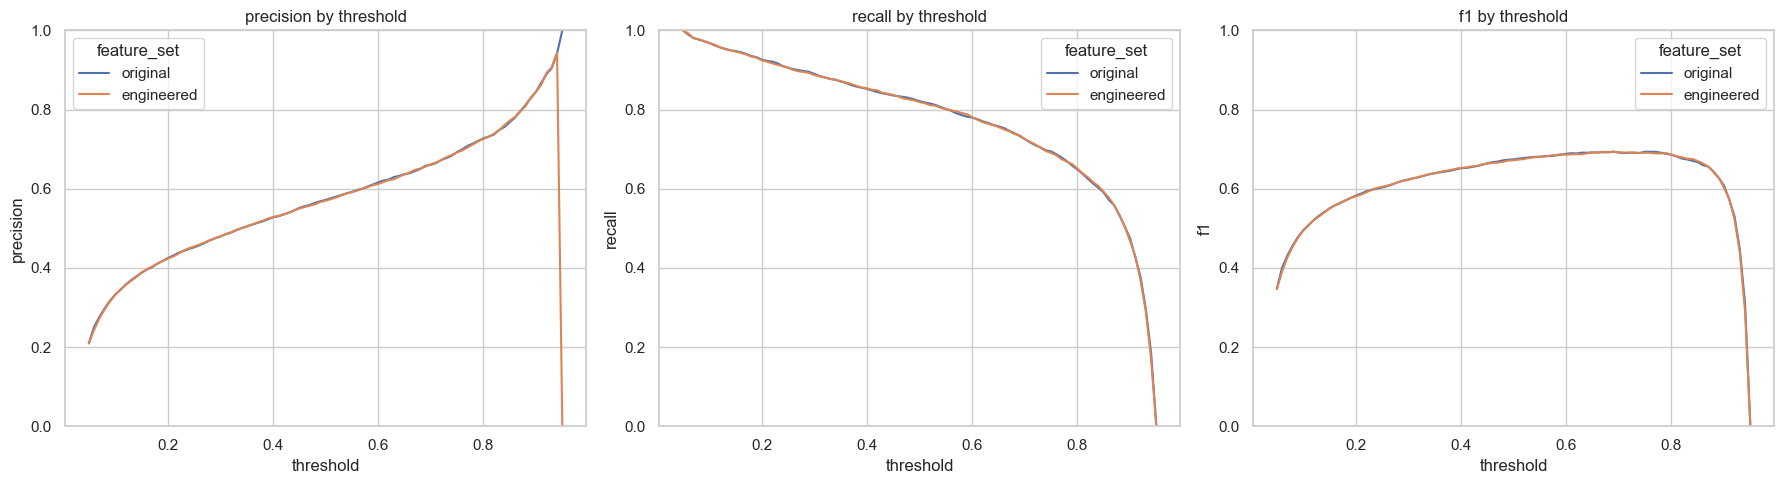

In [9]:
threshold_plot_df = pd.concat([
    results['original']['threshold_result'].assign(feature_set='original'),
    results['engineered']['threshold_result'].assign(feature_set='engineered'),
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    sns.lineplot(data=threshold_plot_df, x='threshold', y=metric, hue='feature_set', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric} by threshold')
plt.tight_layout()
plt.show()

**Threshold Curve 해석**

- threshold curve에서도 engineered feature set이 뚜렷하게 우위에 있다고 보기 어렵다.
- engineered는 특정 threshold 구간에서 recall을 약간 더 확보하지만, precision 손실이 함께 발생한다.
- f1의 최고점도 원본보다 높지 않으므로, threshold 조정 관점에서도 1차 피처 엔지니어링의 이득은 제한적이다.

## 9. Decile / Lift 비교

F1과 PR AUC가 크게 오르지 않더라도, 상위 위험군에 이탈자가 더 잘 모이면 캠페인 관점에서는 개선이다. 원본 피처와 engineered 피처의 decile/lift를 비교한다.

In [10]:
def make_decile_summary(y_true, y_score, feature_set):
    temp = pd.DataFrame({
        'actual_churn': y_true.to_numpy(),
        'churn_probability': y_score,
    }).sort_values('churn_probability', ascending=False).reset_index(drop=True)
    temp['rank'] = np.arange(1, len(temp) + 1)
    temp['decile'] = pd.qcut(temp['rank'], q=10, labels=np.arange(1, 11)).astype(int)
    overall_churn_rate = temp['actual_churn'].mean()
    total_churners = temp['actual_churn'].sum()
    out = temp.groupby('decile').agg(
        customers=('actual_churn', 'size'),
        churners=('actual_churn', 'sum'),
        churn_rate=('actual_churn', 'mean'),
        avg_predicted_probability=('churn_probability', 'mean'),
    ).reset_index()
    out['lift'] = out['churn_rate'] / overall_churn_rate
    out['cumulative_churn_capture'] = out['churners'].cumsum() / total_churners
    out['feature_set'] = feature_set
    return out

original_decile = make_decile_summary(y_test, results['original']['score'], 'original')
engineered_decile = make_decile_summary(y_test, results['engineered']['score'], 'engineered')
decile_comparison = pd.concat([original_decile, engineered_decile], ignore_index=True)

decile_comparison.pivot(index='decile', columns='feature_set', values='churn_rate')

feature_set,engineered,original
decile,,
1,0.869,0.872
2,0.540,0.545
3,0.305,0.300
4,0.159,0.161
5,0.105,0.100
6,0.043,0.045
7,0.026,0.023
8,0.016,0.017
9,0.021,0.023


**Decile / Lift 비교 해석**

- Decile 1 churn rate는 원본 87.2%, engineered 86.9%로 원본이 약간 높다.
- Decile 2도 원본 54.5%, engineered 54.0%로 원본이 높다.
- Decile 3에서는 engineered가 30.5%로 원본 30.0%보다 약간 높지만, 상위 10~20% 핵심 타겟 구간에서는 원본이 더 좋다.
- 하위 decile에서도 큰 차이는 없고, 전체 ranking 구조가 개선됐다고 보기 어렵다.
- 캠페인 관점에서 가장 중요한 상위 위험군 집중도가 오르지 않았으므로, 1차 engineered feature set은 decile/lift 기준으로도 채택하기 어렵다.

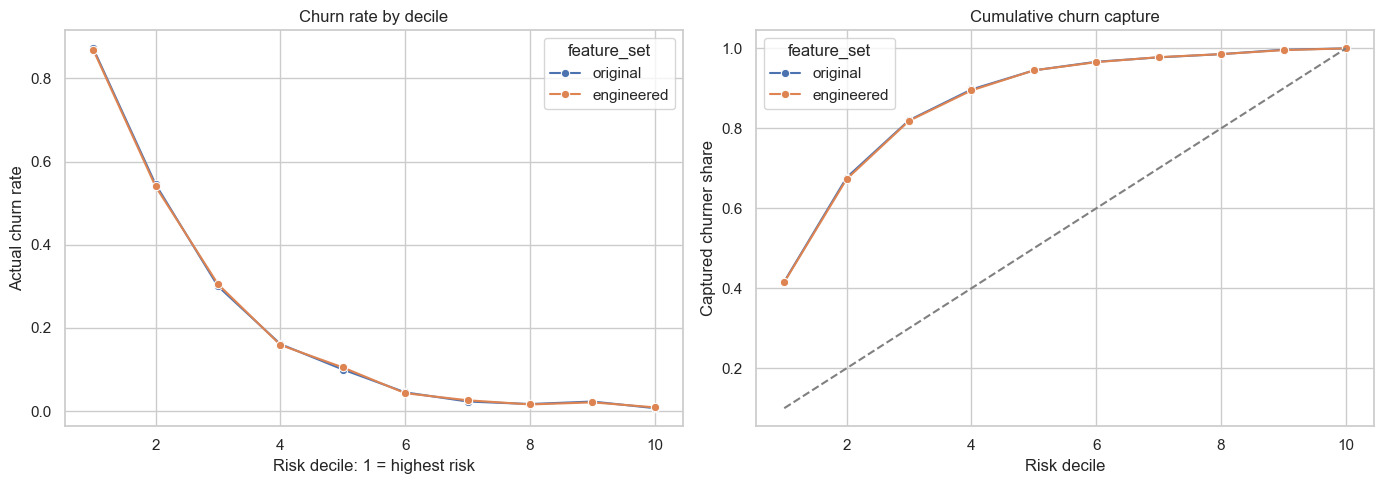

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=decile_comparison, x='decile', y='churn_rate', hue='feature_set', marker='o', ax=axes[0])
axes[0].set_title('Churn rate by decile')
axes[0].set_xlabel('Risk decile: 1 = highest risk')
axes[0].set_ylabel('Actual churn rate')

sns.lineplot(data=decile_comparison, x='decile', y='cumulative_churn_capture', hue='feature_set', marker='o', ax=axes[1])
axes[1].plot([1, 10], [0.1, 1.0], color='gray', linestyle='--')
axes[1].set_title('Cumulative churn capture')
axes[1].set_xlabel('Risk decile')
axes[1].set_ylabel('Captured churner share')

plt.tight_layout()
plt.show()

## 10. First Try 실험 기록

1차 피처 엔지니어링은 원본 피처 대비 성능 개선에 실패했다.

추가 피처 그룹:

- ratio / intensity features
- engagement score features
- behavior risk flags
- high-risk interaction flags
- coarse bin categorical features
- categorical combination features

결과 요약:

- 원본 PR AUC: 0.7642
- engineered PR AUC: 0.7638
- PR AUC 변화: -0.0004
- 원본 threshold 조정 f1: 0.6938
- engineered threshold 조정 f1: 0.6933
- f1 변화: -0.0005
- engineered recall은 threshold 조정 기준 +0.0124 상승했지만, precision이 -0.0105 하락했다.
- Decile 1 churn rate도 원본 87.2%, engineered 86.9%로 개선되지 않았다.

해석:

이번 파생변수들은 `06`에서 확인한 고위험 고객 특성을 잘 반영했지만, 모델 성능 개선으로 이어지지는 않았다. 가능한 이유는 다음과 같다.

- Stacking 모델이 원본 수치형/범주형 피처에서 이미 해당 패턴을 충분히 학습했을 가능성이 크다.
- bin과 flag가 연속형 정보의 세밀함을 일부 잃게 만들었을 수 있다.
- interaction/combo 피처가 one-hot 차원을 늘렸지만 추가 정보량은 제한적이었을 수 있다.
- 파생변수 대부분이 기존 강한 변수인 `days_since_last_login`, 시청량, completion, recommendation click의 변형이라 중복 신호가 많았을 수 있다.

다음 실험 방향:

- 모든 파생변수를 한 번에 넣기보다 그룹별 ablation을 한다.
- `ratio only`, `flags only`, `bins only`, `interactions only`로 나누어 어떤 그룹이 해로운지 확인한다.
- Stacking 전에 Logistic Regression 또는 XGBoost 단일 모델로 빠르게 후보 피처를 선별하는 것도 고려한다.
- 연속형 변수를 bin으로 대체하지 말고, 원본 + 일부 핵심 ratio만 추가하는 더 작은 피처 세트를 시도한다.

현재 결론은 “1차 피처 엔지니어링은 채택하지 않고, 원본 피처 기반 Stacking을 유지한다”이다.
